In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')

from collections import defaultdict
import pickle
import numpy as np
import os
import torch
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import matplotlib.transforms as transforms
from matplotlib.ticker import LogLocator
import seaborn as sns
import string

from pathos.multiprocessing import ProcessPool as Pool

from sbi.inference import NPE
from sbi.utils.user_input_checks import process_prior

from utils import simulate_one, get_prior, get_model_and_rbg_data, create_patient_df
from eval_utils import compute_cgm_metrics, compute_params_metrics, print_summary



In [3]:
def add_letters(fig, ax, dx=-35/72., dy=15/72.):
    
    letterkwargs = dict(weight='bold', va='top', ha='left')

    offset = transforms.ScaledTranslation(
            dx, dy, fig.dpi_scale_trans)

    for idx in range(len(ax)):
        ax[idx].text(0, 1, string.ascii_lowercase[idx], transform=ax[idx].transAxes + offset, 
                    **letterkwargs)


# Load trained model

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model and prior
model, rbg_data = get_model_and_rbg_data('./data/data_day_1.csv', './data/patient_info.csv', fixed_beta=True)
custom_prior = get_prior(VG=model.model_parameters.VG, 
                         device=device, 
                         fixed_beta=True)
prior, _, _ = process_prior(custom_prior)

inference = NPE(prior=prior, device=device)
density_estimator = torch.load('./trained_models/pretrained_density_estimator2.pt', map_location=device, weights_only=False)
posterior = inference.build_posterior(density_estimator)


Using device: cuda


# Parameter evaluation

In [22]:
test_data["cgms"].shape

(266, 264)

In [5]:
param_list = ['Gb', 'SG', 'p2', 'ka2', 'kd', 'kempt', 'SI', 'kabs']
test_data = torch.load('./data/simulated2/test_data.pt', weights_only=False)

test_theta = torch.tensor(test_data["thetas"], dtype=torch.float32).to(device)
test_x_np = np.concatenate([test_data["cgms"], test_data["basals"] + test_data["boluses"]], axis=1)
test_x = torch.tensor(test_x_np, dtype=torch.float32).to(device)
    
our_metrics = defaultdict(list)
replay_metrics = defaultdict(list)
map_metrics = defaultdict(list)

for idx in range(5):
    with open(f'./results/mcmc/mcmc_mcmc_data_day_1_{idx}.pkl', 'rb') as f:
        replay_bg_pred = pickle.load(f)

    with open(f'./results/map/map_map_data_day_1_{idx}.pkl', 'rb') as f:
        map_pred = pickle.load(f)

    if os.path.isfile(f'./sbi_results/SBI_res_{idx}.pt'):
        samples, _ = torch.load(f'./sbi_results/SBI_res_{idx}.pt', weights_only=False)
    else:
        data = create_patient_df(t=test_data['t'][idx],
                         glucose=test_data['cgms'][idx],
                         cho=test_data['meals'][idx],
                         bolus=test_data['boluses'][idx],
                         basal=test_data['basals'][idx])
        model, rbg_data = get_model_and_rbg_data(data, patient_info_path='./data/patient_info.csv', fixed_beta=True)
        samples, samples_x = [], []
        while len(samples) < 1000:
            batch_samples = posterior.sample((1000,), x=test_x[idx].to(device)).to(device)
            print(batch_samples.shape)
            log_probs = prior.log_prob(batch_samples[:, :8]) 
            # Mask out samples with -inf log prob
            mask = torch.isfinite(log_probs)
            batch_samples = batch_samples[mask]
            
            input_data = [
                (batch_samples[i][:8].cpu().numpy(), model, rbg_data, None, False, batch_samples[i][8:].cpu().numpy() )
                for i in range(batch_samples.shape[0])
            ]
            for sadasd in input_data:
                simulate_one(sadasd)
            with Pool() as pool:
                results = pool.map(simulate_one, input_data)
            for i, (_, x, cgm, _, _, _) in enumerate(results):
                if cgm is not None and cgm.max() <= 400 and cgm.min() >= 40 and (x >=0).all():
                    samples_x.append(cgm)
                    samples.append(batch_samples[i])
        torch.save([samples, samples_x], f'./sbi_results/SBI_res_{idx}.pt')

    samples_np = torch.stack(samples)[:1000, :8].cpu().numpy()
    
    true_theta = test_theta[idx][:8].cpu().numpy()

    for i, param in enumerate(param_list):
        our_param_samples = samples_np[:, i]
        replay_param_samples = replay_bg_pred['draws'][param]['samples_1000']
        map_param_samples = map_pred['draws'][param] * np.ones_like(replay_param_samples)
        true_param_val = true_theta[i]

        our_metrics[param].append(compute_params_metrics(our_param_samples, true_param_val))
        replay_metrics[param].append(compute_params_metrics(replay_param_samples, true_param_val))
        map_metrics[param].append(compute_params_metrics(map_param_samples, true_param_val))


In [6]:
latex_labels = ["$G_b$", "$SG$", "$p_2$", "$k_{a2}$", "$k_d$", "$k_{empt}$", "$SI$", "$k_{abs}$"]

data = {
    "Parameter": [],
    "Method": [],
    "Abs Error": [],
    "Rel Error": [],
    "MAD": [],
    "Coverage": []
}

for param, latex_label in zip(param_list, latex_labels):
    our_summary = np.mean(our_metrics[param], axis=0)
    replay_summary = np.mean(replay_metrics[param], axis=0)
    map_summary = np.mean(map_metrics[param], axis=0)
    
    for method, summary in zip(["MAP", "ReplayBG", "SBI"], [map_summary, replay_summary, our_summary]):
        data["Parameter"].append(latex_label)
        data["Method"].append(method)
        data["Abs Error"].append(summary[0])
        data["Rel Error"].append(summary[1])
        data["MAD"].append(summary[2])
        data["Coverage"].append(summary[3] * 100)

df = pd.DataFrame(data)
df

,Parameter,Method,Abs Error,Rel Error,MAD,Coverage
0,$G_b$,MAP,12.093172,10.173996,12.093172,0.0
1,$G_b$,ReplayBG,12.038798,10.128725,12.033081,20.0
2,$G_b$,SBI,1.932047,1.628934,3.537918,100.0
3,$SG$,MAP,0.005050,12.400018,0.005050,0.0
4,$SG$,ReplayBG,0.004772,11.754294,0.005077,40.0
5,$SG$,SBI,0.002176,5.891622,0.004888,100.0
6,$p_2$,MAP,0.001908,15.546407,0.001908,0.0
7,$p_2$,ReplayBG,0.001557,12.736806,0.001580,60.0
8,$p_2$,SBI,0.000493,4.207584,0.000867,100.0
9,$k_{a2}$,MAP,0.004549,45.247081,0.004549,0.0


In [7]:
df.groupby("Method")["Coverage"].mean()

Method
MAP          0.0
ReplayBG    30.0
SBI         97.5
Name: Coverage, dtype: float64

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following famil

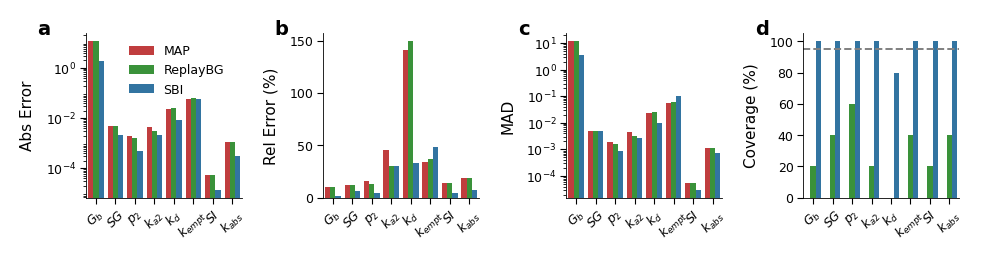

In [8]:
metrics = ["Abs Error", "Rel Error", "MAD", "Coverage"]
TEXTWIDTH = 12.19826 / 2.54  # cm → inch
FIGWIDTH = TEXTWIDTH

with plt.style.context("./plot_style.txt"):

    fig, axes = plt.subplots(1, 4, figsize=(FIGWIDTH, 0.25 * FIGWIDTH), sharex=True, layout='constrained')
    fig.subplots_adjust(wspace=0.0, hspace=0.4)

    palette = {"MAP": "tab:red", "ReplayBG": "tab:green", "SBI": "tab:blue"}

    for ax, metric in zip(axes, metrics):
        sns.barplot(data=df, x="Parameter", y=metric, hue="Method", ax=ax, palette=palette)
        ax.set_xlabel("")
        if metric in ["Rel Error", "Coverage"]:
            metric += " (%)"
        ax.set_ylabel(metric, fontsize=5.5)
        # ax.set_title(metric, fontsize=10)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        ax.tick_params(axis='x', labelsize=4.5)
        ax.tick_params(axis='y', labelsize=4.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(False)



        if metric in ["Abs Error", "MAD"] and df[metric].max() > 10:
            ax.set_yscale("log")

            ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=10))
            ax.yaxis.set_minor_formatter(plt.NullFormatter())  # Hide minor tick labels
        if metric.startswith("Coverage"):
            ax.axhline(95, color="gray", linestyle="--", linewidth=0.7)
        # Shared legend
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

        if metric == "Abs Error":
            ax.legend(handles, labels, frameon=False, bbox_to_anchor=(0.2,0.55), fontsize=4.5)

    # # Shared legend
    # handles, labels = axes[0].get_legend_handles_labels()
    # for ax in axes:
    #     ax.get_legend().remove()

    # fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=9.5,
    #         bbox_to_anchor=(0.5, 1.17), bbox_transform=fig.transFigure)

    add_letters(fig, axes, dx=-17.5/72., dy=5/72.) 

    plt.savefig("plots/benchmark_metrics_1x4.pdf", bbox_inches='tight')
    plt.show()
    

## Posterior visualization

In [9]:
idx = 19

with open(f'./results/mcmc/mcmc_mcmc_data_day_1_{idx}.pkl', 'rb') as f:
    replay_bg_pred = pickle.load(f)

with open(f'./results/map/map_map_data_day_1_{idx}.pkl', 'rb') as f:
    map_pred = pickle.load(f)

samples, _ = torch.load(f'./sbi_results/SBI_res_{idx}.pt', weights_only=False)
samples_np = torch.stack(samples)[:1000, :8].cpu().numpy()
true_theta = test_theta[idx][:8].numpy()

replay_param_samples = np.vstack([
    replay_bg_pred['draws'][param]['samples_1000'] for param in param_list
]).T

map_param_samples = np.vstack([
    map_pred['draws'][param] * np.ones_like(replay_bg_pred['draws'][param]['samples_1000'])
    for param in param_list
]).T[0]

n_params = samples_np.shape[1]
fig, axes = plt.subplots(n_params, n_params, figsize=(20, 20))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]
        if j < i:
            ax.axis('off')
            continue

        if i == j:
            sns.kdeplot(samples_np[:, i], ax=ax, color='tab:blue', fill=True, alpha=0.3, label='SBI')
            sns.kdeplot(replay_param_samples[:, i], ax=ax, color='tab:green', fill=True, alpha=0.3, label='ReplayBG')
            ax.axvline(map_param_samples[i], color='tab:red', linestyle='-', label='MAP')
            ax.axvline(true_theta[i], color='black', linestyle='-', label='True')
            ax.set_xlabel(latex_labels[i], fontsize=30)
            if i == 0:
                ax.legend(frameon=False, fontsize=30, loc='lower center', bbox_to_anchor=(0.9, -5.2))
        else:
            sns.kdeplot(x=samples_np[:, j], y=samples_np[:, i], ax=ax, color='tab:blue', levels=5, linewidths=1)
            sns.kdeplot(x=replay_param_samples[:, j], y=replay_param_samples[:, i], ax=ax, color='tab:green', levels=5, linewidths=1, linestyles='-')
            ax.plot(map_param_samples[j], map_param_samples[i], marker='o', color='tab:red')
            ax.plot(true_theta[j], true_theta[i], marker='o', color='black')

            if i < n_params - 1:
                ax.set_xticklabels([])

        ax.set_yticks([])
        ax.set_ylabel('')
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=13)

plt.savefig("plots/posterior.pdf", bbox_inches='tight')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: './results/mcmc/mcmc_mcmc_data_day_1_19.pkl'

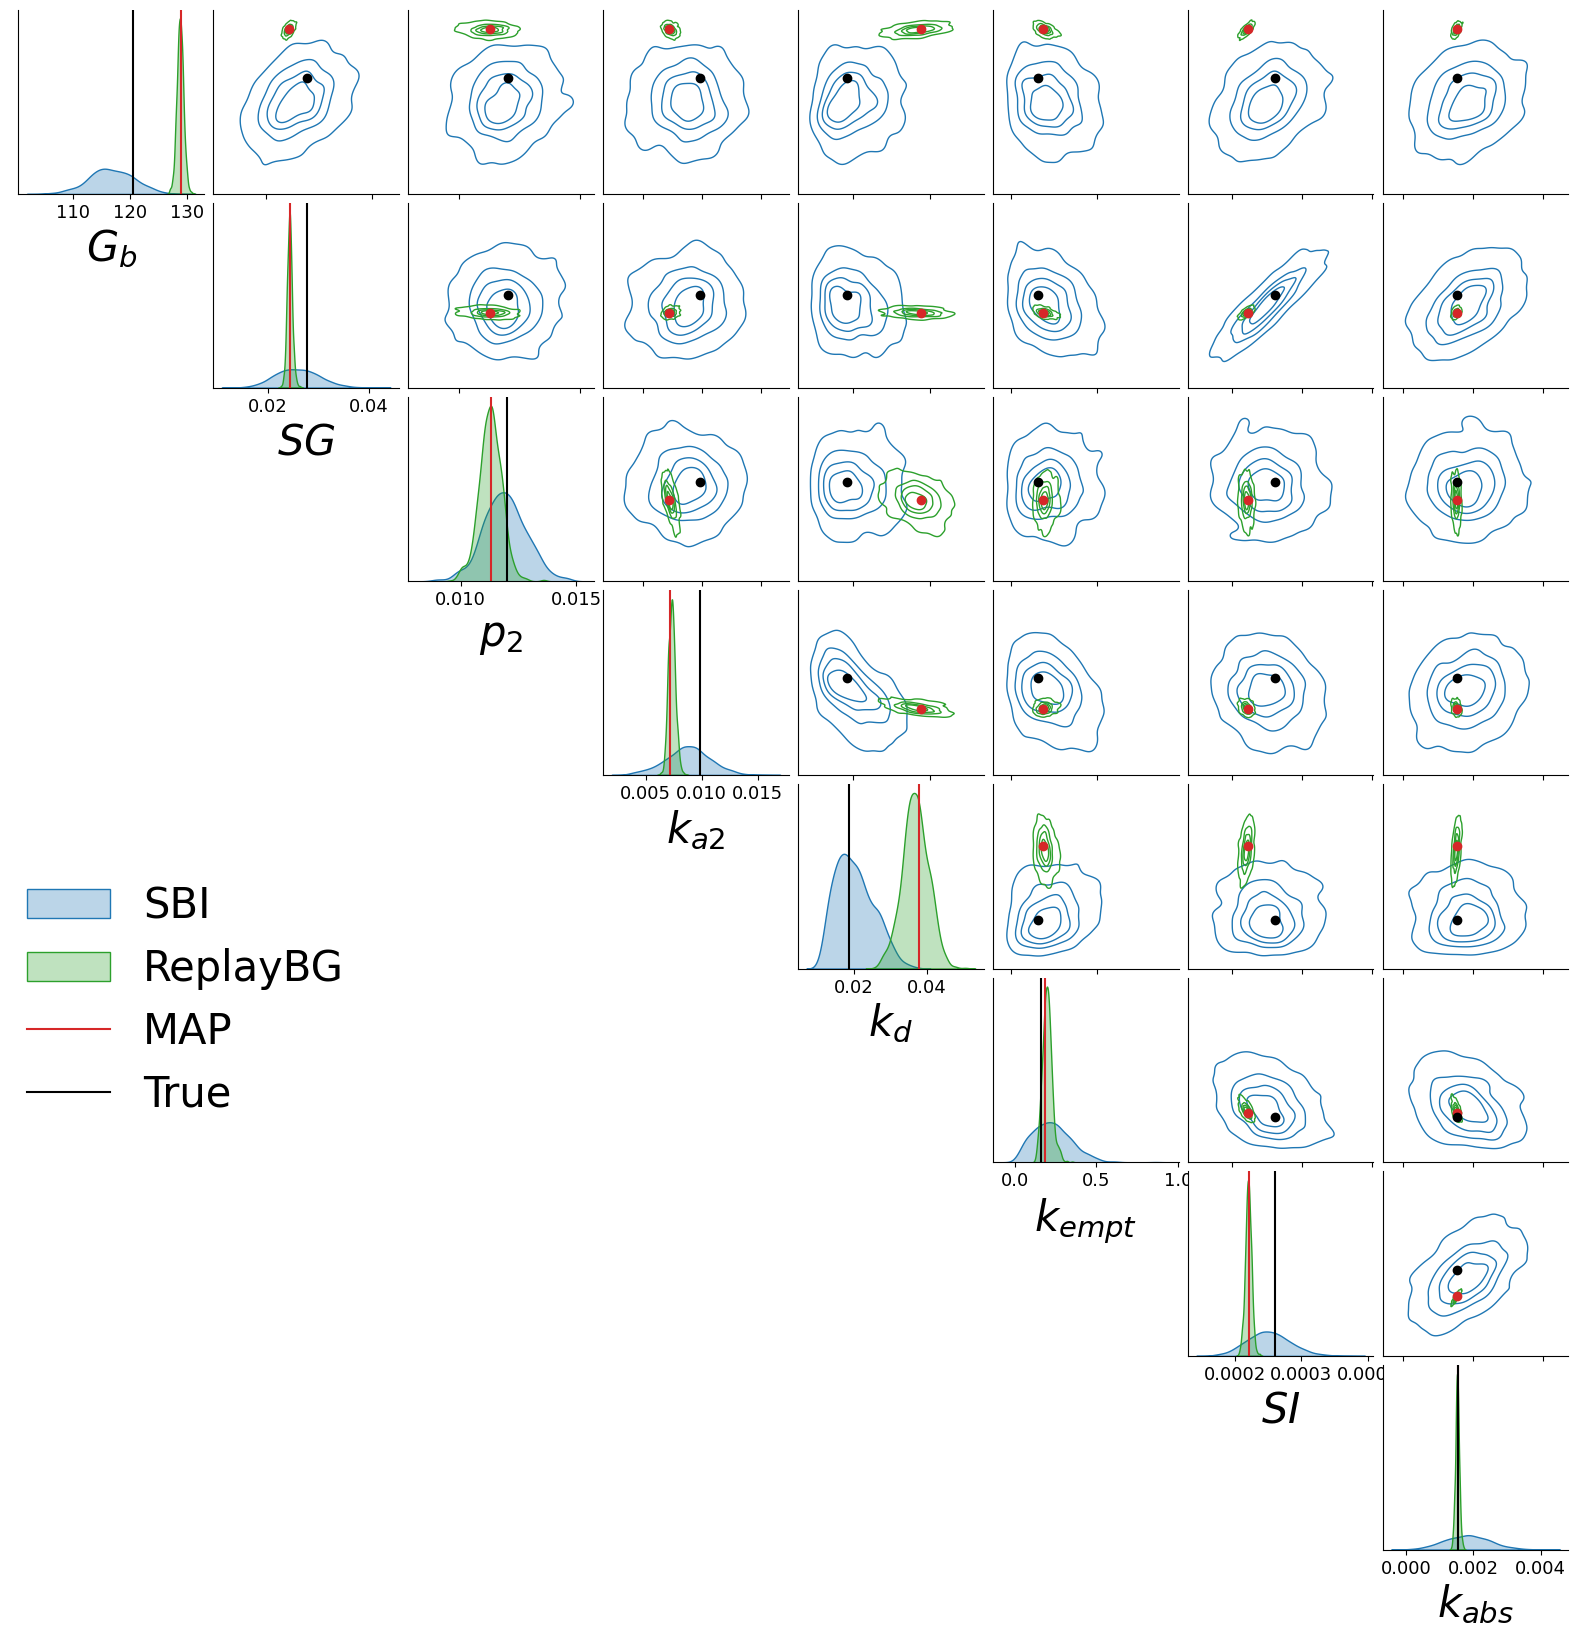

In [11]:
idx = 1

with open(f'./results/mcmc/mcmc_mcmc_data_day_1_{idx}.pkl', 'rb') as f:
    replay_bg_pred = pickle.load(f)

with open(f'./results/map/map_map_data_day_1_{idx}.pkl', 'rb') as f:
    map_pred = pickle.load(f)

samples, _ = torch.load(f'./sbi_results/SBI_res_{idx}.pt', weights_only=False)
samples_np = torch.stack(samples)[:1000, :8].cpu().numpy()
true_theta = test_theta[idx][:8].cpu().numpy()

replay_param_samples = np.vstack([
    replay_bg_pred['draws'][param]['samples_1000'] for param in param_list
]).T

map_param_samples = np.vstack([
    map_pred['draws'][param] * np.ones_like(replay_bg_pred['draws'][param]['samples_1000'])
    for param in param_list
]).T[0]

n_params = samples_np.shape[1]
fig, axes = plt.subplots(n_params, n_params, figsize=(20, 20))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]
        if j < i:
            ax.axis('off')
            continue

        if i == j:
            sns.kdeplot(samples_np[:, i], ax=ax, color='tab:blue', fill=True, alpha=0.3, label='SBI')
            sns.kdeplot(replay_param_samples[:, i], ax=ax, color='tab:green', fill=True, alpha=0.3, label='ReplayBG')
            ax.axvline(map_param_samples[i], color='tab:red', linestyle='-', label='MAP')
            ax.axvline(true_theta[i], color='black', linestyle='-', label='True')
            ax.set_xlabel(latex_labels[i], fontsize=30)
            if i == 0:
                ax.legend(frameon=False, fontsize=30, loc='lower center', bbox_to_anchor=(0.9, -5.2))
        else:
            sns.kdeplot(x=samples_np[:, j], y=samples_np[:, i], ax=ax, color='tab:blue', levels=5, linewidths=1)
            sns.kdeplot(x=replay_param_samples[:, j], y=replay_param_samples[:, i], ax=ax, color='tab:green', levels=5, linewidths=1, linestyles='-')
            ax.plot(map_param_samples[j], map_param_samples[i], marker='o', color='tab:red')
            ax.plot(true_theta[j], true_theta[i], marker='o', color='black')

            if i < n_params - 1:
                ax.set_xticklabels([])

        ax.set_yticks([])
        ax.set_ylabel('')
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=13)

plt.savefig("plots/posterior_1.pdf", bbox_inches='tight')
plt.show()


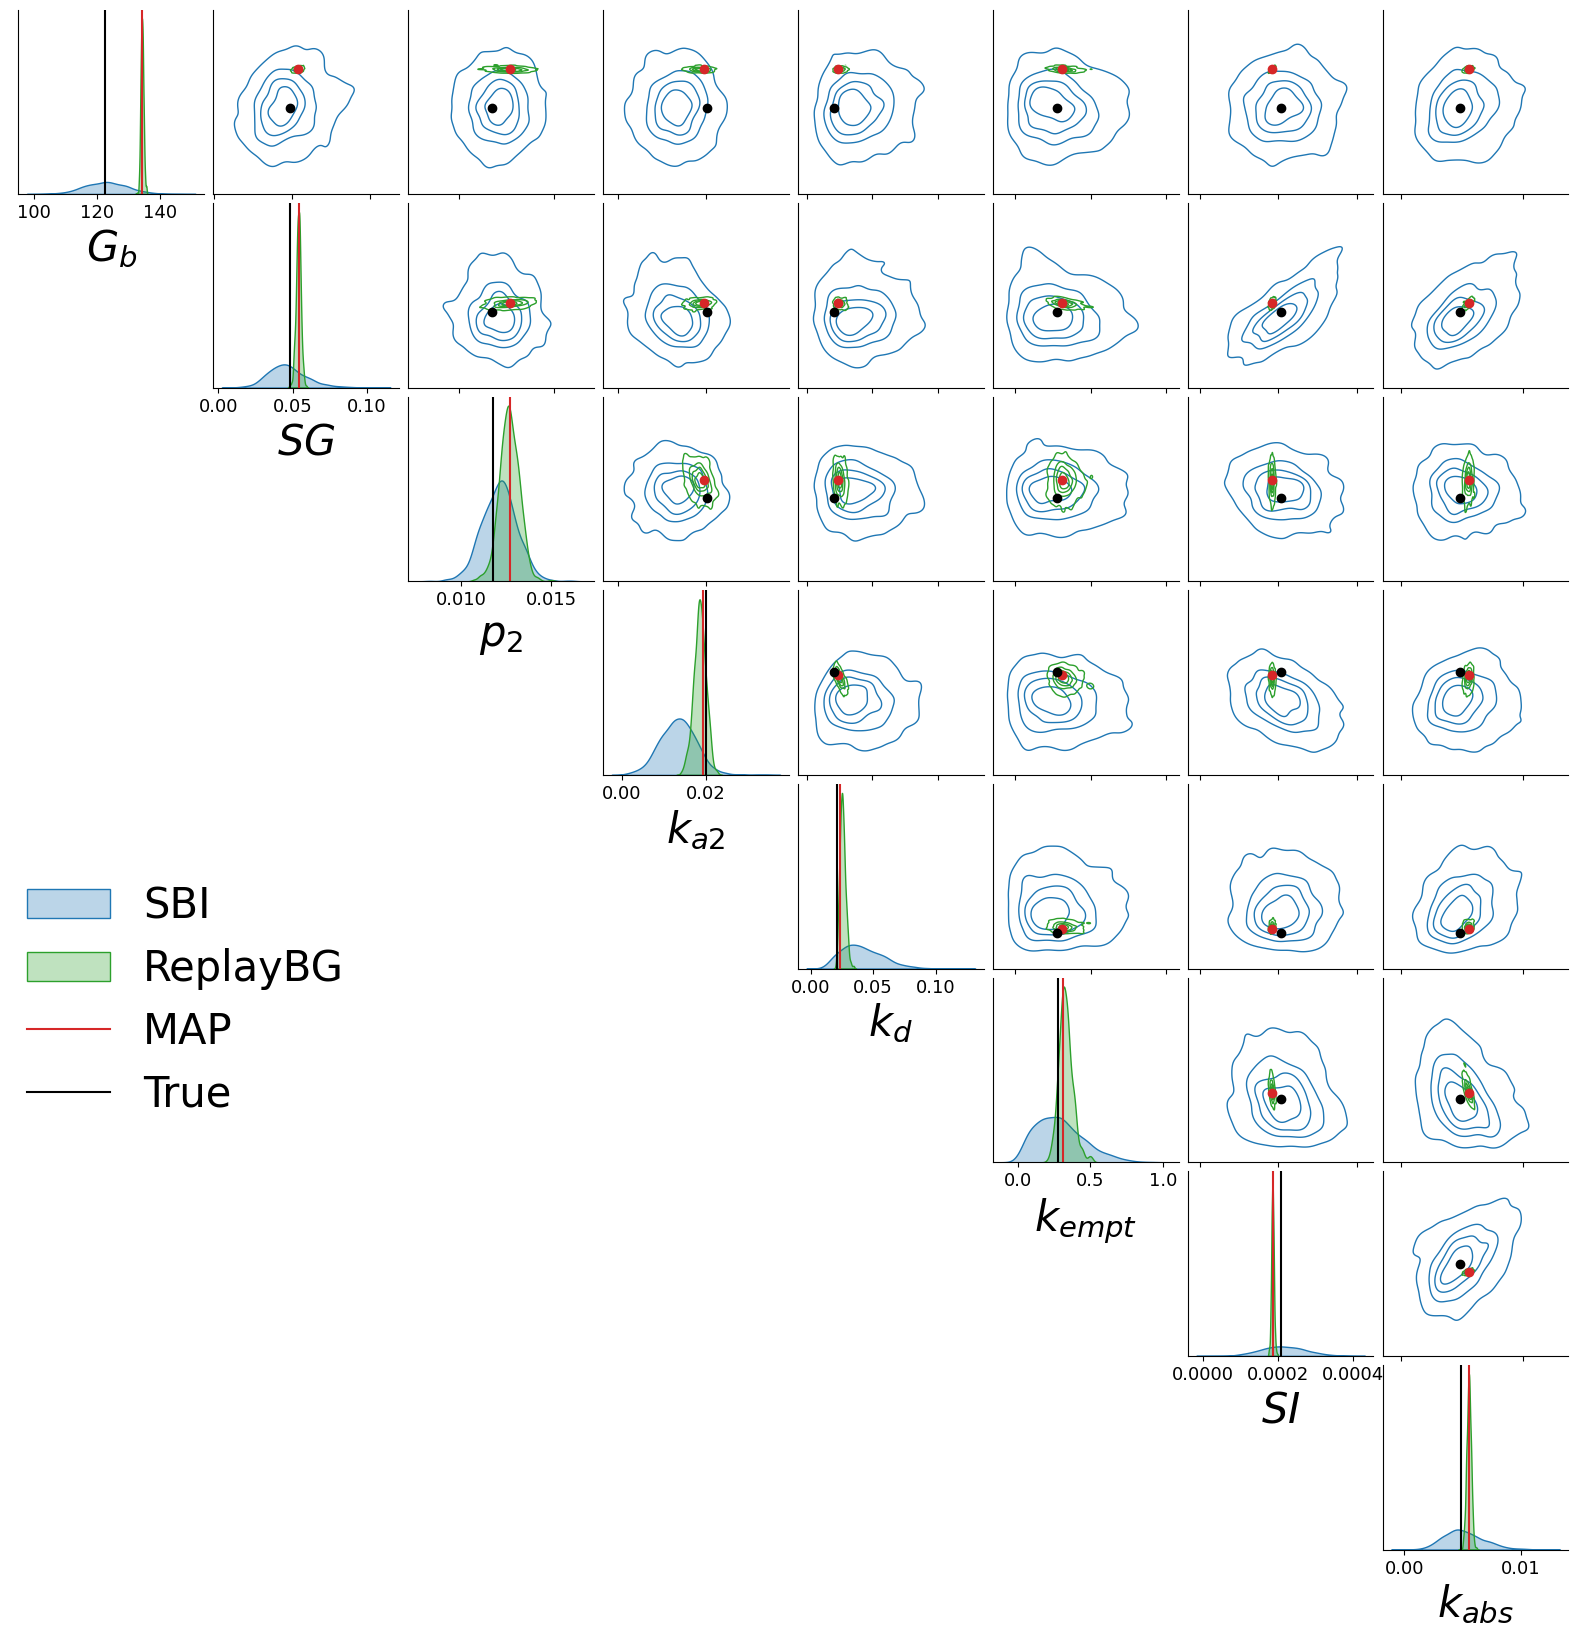

In [11]:
idx = 49

with open(f'./results/mcmc/mcmc_mcmc_data_day_1_{idx}.pkl', 'rb') as f:
    replay_bg_pred = pickle.load(f)

with open(f'./results/map/map_map_data_day_1_{idx}.pkl', 'rb') as f:
    map_pred = pickle.load(f)

samples, _ = torch.load(f'./sbi_results/SBI_res_{idx}.pt', weights_only=False)
samples_np = torch.stack(samples)[:1000, :8].cpu().numpy()
true_theta = test_theta[idx][:8].numpy()

replay_param_samples = np.vstack([
    replay_bg_pred['draws'][param]['samples_1000'] for param in param_list
]).T

map_param_samples = np.vstack([
    map_pred['draws'][param] * np.ones_like(replay_bg_pred['draws'][param]['samples_1000'])
    for param in param_list
]).T[0]

n_params = samples_np.shape[1]
fig, axes = plt.subplots(n_params, n_params, figsize=(20, 20))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]
        if j < i:
            ax.axis('off')
            continue

        if i == j:
            sns.kdeplot(samples_np[:, i], ax=ax, color='tab:blue', fill=True, alpha=0.3, label='SBI')
            sns.kdeplot(replay_param_samples[:, i], ax=ax, color='tab:green', fill=True, alpha=0.3, label='ReplayBG')
            ax.axvline(map_param_samples[i], color='tab:red', linestyle='-', label='MAP')
            ax.axvline(true_theta[i], color='black', linestyle='-', label='True')
            ax.set_xlabel(latex_labels[i], fontsize=30)
            if i == 0:
                ax.legend(frameon=False, fontsize=30, loc='lower center', bbox_to_anchor=(0.9, -5.2))
        else:
            sns.kdeplot(x=samples_np[:, j], y=samples_np[:, i], ax=ax, color='tab:blue', levels=5, linewidths=1)
            sns.kdeplot(x=replay_param_samples[:, j], y=replay_param_samples[:, i], ax=ax, color='tab:green', levels=5, linewidths=1, linestyles='-')
            ax.plot(map_param_samples[j], map_param_samples[i], marker='o', color='tab:red')
            ax.plot(true_theta[j], true_theta[i], marker='o', color='black')

            if i < n_params - 1:
                ax.set_xticklabels([])

        ax.set_yticks([])
        ax.set_ylabel('')
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=13)

plt.savefig("plots/posterior_49.pdf", bbox_inches='tight')
plt.show()


# CGM evaluation

In [44]:
def load_or_simulate_replay_samples(idx, model_idx, rbg_data_idx, param_list, extended=False, noise=False):
    suffix = '_extended' if extended else ''
    suffix = '_noise' if noise else suffix
    cache_path = f'./results/replay/mcmc_data_day_1_{idx}{suffix}.pt'
    
    if not extended and not noise and os.path.isfile(f'./results/workspaces/mcmc_data_day_1_{idx}_step_2a.pkl'):
        with open(f'./results/workspaces/mcmc_data_day_1_{idx}_step_2a.pkl', 'rb') as f:
            data = pickle.load(f)
        replay_x_samples = np.stack(data['cgm']['realizations'])
    elif os.path.isfile(cache_path):
        replay_x_samples = torch.load(cache_path, weights_only=False)
    else:
        with open(f'./results/mcmc/mcmc_mcmc_data_day_1_{idx}.pkl', 'rb') as f:
            replay_bg_pred = pickle.load(f)
        replay_samples = np.stack([replay_bg_pred['draws'][param]['samples_1000'] for param in param_list]).T
        input_data = [(replay_samples[i], model_idx, rbg_data_idx, None, False, None) for i in range(replay_samples.shape[0])]
        with Pool() as pool:
            results = pool.map(simulate_one, input_data)
        replay_x_samples = np.stack([r[2] for r in results if r[0] is not None])
        torch.save(replay_x_samples, cache_path)
    return replay_x_samples

def load_or_simulate_map_median(idx, model_idx, rbg_data_idx, param_list, extended=False, noise=False):
    suffix = '_extended' if extended else ''
    suffix = '_noise' if noise else suffix
    cache_path = f'./results/replay/map_data_day_1_{idx}{suffix}.pt'
    
    if not extended and not noise and os.path.isfile(f'./results/workspaces/map_data_day_1_{idx}_step_2a.pkl'):
        with open(f'./results/workspaces/map_data_day_1_{idx}_step_2a.pkl', 'rb') as f:
            data = pickle.load(f)
        map_x_median = data['cgm']['realizations'][0]
    elif os.path.isfile(cache_path):
        map_x_median = torch.load(cache_path, weights_only=False)
    else:
        with open(f'./results/map/map_map_data_day_1_{idx}.pkl', 'rb') as f:
            map_pred = pickle.load(f)
        map_samples = np.array([map_pred['draws'][param] for param in param_list])
        map_x_median = simulate_one((map_samples, model_idx, rbg_data_idx, None, False, None))[2]
        torch.save(map_x_median, cache_path)
    return map_x_median

def load_or_simulate_sbi_results(idx, model_idx, rbg_data_idx, extended=False, noise=False):
    suffix = '_extended' if extended else ''
    suffix = '_noise' if noise else suffix
    cache_path = f'./sbi_results/SBI_res_{idx}{suffix}.pt'

    if not os.path.isfile(cache_path):
        samples, _ = torch.load(f'./sbi_results/SBI_res_{idx}.pt', weights_only=False)
        input_data = [(samples[i][:8].cpu().numpy(), model_idx, rbg_data_idx, None, False, samples[i][8:].cpu().numpy() ) for i in range(len(samples))]
        with Pool() as pool:
            results = pool.map(simulate_one, input_data)
        pred_x_samples = [r[2] for r in results if r[0] is not None]
        torch.save([samples, pred_x_samples], cache_path)
    else:
        _, pred_x_samples = torch.load(cache_path, weights_only=False)
    return np.stack(pred_x_samples)


In [56]:
def evaluate(test_theta, test_data, param_list, extended=False, noise=False):
    assert extended == False, "Not support extended yet"
    our_mard, our_rmsd = [], []
    replay_mard, replay_rmsd = [], []
    map_mard, map_rmsd = [], []
    test_theta = test_data["thetas"]
    test_x0s = test_data["x0s"]
    for idx in range(5):
        if noise:
            # Boolean mask for non-zero entries
            cho = test_data['meals'][idx].copy()
            mask = cho != 0  

            # Generate noise proportional to current values
            noise_cho = np.random.normal(loc=0.0, scale=0.1, size=mask.sum()) * cho[mask]

            # Add noise and clip to avoid negatives
            cho[mask] = np.clip(cho[mask] + noise_cho, a_min=0, a_max=None)
        else:
            cho = test_data['meals'][idx]
        
        data = create_patient_df(t=test_data['t'][idx],
                 glucose=test_data['cgms'][idx],
                 cho=cho,
                 bolus=test_data['boluses'][idx],
                 basal=test_data['basals'][idx])
        model_idx, rbg_data_idx = get_model_and_rbg_data(data, patient_info_path='./data/patient_info.csv', fixed_beta=True)
        
        # model_idx, rbg_data_idx = get_model_and_rbg_data(
        #     './data/data_day_1_extended.csv' if extended else './data/data_day_1.csv',
        #     './data/patient_info.csv',
        #     test_x[idx].cpu().numpy(),
        #     cho=noise_meals[idx] if noise else None,
        #     fixed_beta=True,
        # )

        # Handle true extended or noise data caching
        if extended or noise:
            true_cache_path = f'./data/simulated2/data_day_1_{idx}{"_extended" if extended else "_noise"}.pt'
            if os.path.isfile(true_cache_path):
                true_x = torch.load(true_cache_path, weights_only=False)
            else:
                true_x = simulate_one((test_theta[idx], model_idx, rbg_data_idx, None, False, test_x0s[idx]))[2]
                torch.save(true_x, true_cache_path)
            if extended:
                true_x = true_x[test_x.shape[1]:]  # Use only extended part
        else:
            true_x = test_data['cgms'][idx]
            
        pred_x_samples = load_or_simulate_sbi_results(idx, model_idx, rbg_data_idx, extended=extended, noise=noise)
        pred_x_median = np.median(pred_x_samples, axis=0)
        if extended:
            pred_x_median = pred_x_median[test_x.shape[1]:]  # Use only extended part

        replay_x_samples = load_or_simulate_replay_samples(idx, model_idx, rbg_data_idx, param_list, extended=extended, noise=noise)
        replay_x_median = np.median(replay_x_samples, axis=0)
        if extended:
            replay_x_median = replay_x_median[test_x.shape[1]:]  # Use only extended part
            
        map_x_median = load_or_simulate_map_median(idx, model_idx, rbg_data_idx, param_list, extended=extended, noise=noise)
        if extended:
            map_x_median = map_x_median[test_x.shape[1]:]  # Use only extended part

        # Compute metrics
        mard, rmsd = compute_cgm_metrics(pred_x_median, true_x)
        our_mard.append(mard)
        our_rmsd.append(rmsd)

        mard, rmsd = compute_cgm_metrics(replay_x_median, true_x)
        replay_mard.append(mard)
        replay_rmsd.append(rmsd)

        mard, rmsd = compute_cgm_metrics(map_x_median, true_x)
        map_mard.append(mard)
        map_rmsd.append(rmsd)

    print_summary('MAP', map_mard, map_rmsd)
    print_summary('ReplayBG', replay_mard, replay_rmsd)
    print_summary('SBI', our_mard, our_rmsd)



## Setting 1

In [47]:
evaluate(test_theta, test_data, param_list, extended=False, noise=False)


MAP MARD: 12.73 ± 5.14%, RMSD: 15.71 ± 4.85
ReplayBG MARD: 5.87 ± 1.77%, RMSD: 7.22 ± 1.67
SBI MARD: 8.50 ± 3.48%, RMSD: 10.95 ± 4.23


## Setting 2

In [49]:
evaluate(test_theta, test_x, param_list, extended=True, noise=False)


AssertionError: Not support extended yet

## Setting 3

In [57]:
evaluate(test_theta, test_data, param_list, extended=False, noise=True)

MAP MARD: 27.32 ± 22.39%, RMSD: 25.43 ± 15.28
ReplayBG MARD: 26.86 ± 18.16%, RMSD: 22.95 ± 12.29
SBI MARD: 16.21 ± 10.69%, RMSD: 14.92 ± 6.88


## CGM Visualization

Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ...

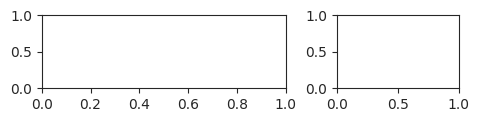

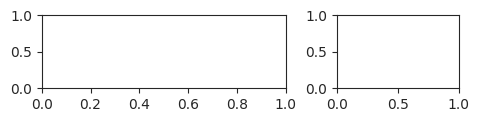

Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ..., 276.0416666666667]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1736 ticks ([-13.125, ...

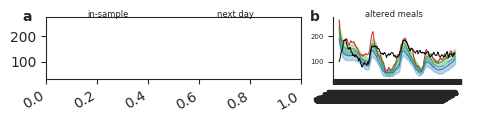

In [60]:
sns.set_style("ticks")

# --- Figure layout settings ---
TEXTWIDTH = 12.19826 / 2.54  # cm to inches
FIGWIDTH = TEXTWIDTH
FIGHEIGHT = 0.23 * FIGWIDTH

fig = plt.figure(figsize=(FIGWIDTH, FIGHEIGHT), layout='constrained')
gs = GridSpec(1, 3, width_ratios=[2, 1, 0.1], wspace=0.01, figure=fig)  # Extra column for legend

# Colors
COLOR_SBI = 'tab:blue'
COLOR_REPLAY = 'tab:green'
COLOR_MAP = 'tab:red'
COLOR_GT = 'black'

# --- LEFT PLOT: extended ---
ax1 = fig.add_subplot(gs[0])

# extended_data = pd.read_csv('./data/data_day_1_extended.csv')
# extended_data.t = pd.to_datetime(extended_data['t'])
# idx1 = 17

# _, pred_x_samples1 = torch.load(f'./sbi_results/SBI_res_{idx1}_extended.pt', weights_only=False)
# replay_x_samples1 = torch.load(f'./results/replay/mcmc_data_day_1_{idx1}_extended.pt', weights_only=False)
# map_replay_x1 = torch.load(f'./results/replay/map_data_day_1_{idx1}_extended.pt', weights_only=False)
# true_x1 = torch.load(f'./data/simulated/data_day_1_{idx1}_extended.pt', weights_only=False)

# pred_mean1 = np.stack(pred_x_samples1).mean(axis=0)
# pred_std1 = np.stack(pred_x_samples1).std(axis=0)
# replay_mean1 = np.stack(replay_x_samples1).mean(axis=0)
# replay_std1 = np.stack(replay_x_samples1).std(axis=0)

# ax1.plot(extended_data.t, map_replay_x1, label='MAP', color=COLOR_MAP, linewidth=0.7)
# ax1.plot(extended_data.t, replay_mean1, label='ReplayBG', color=COLOR_REPLAY, linewidth=0.7)
# ax1.fill_between(extended_data.t, replay_mean1 - replay_std1, replay_mean1 + replay_std1, color=COLOR_REPLAY, alpha=0.3)
# ax1.plot(extended_data.t, pred_mean1, label='SBI', color=COLOR_SBI, linewidth=0.7)
# ax1.fill_between(extended_data.t, pred_mean1 - pred_std1, pred_mean1 + pred_std1, color=COLOR_SBI, alpha=0.3)
# ax1.plot(extended_data.t, true_x1, label='True CGM', color=COLOR_GT, linewidth=0.7)

# ax1.spines['top'].set_visible(False)
# ax1.spines['right'].set_visible(False)
# ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax1.xaxis.set_major_locator(mdates.HourLocator(interval=4))
# mid_time = extended_data.t[len(extended_data.t) // 2]
# ax1.axvline(mid_time, color='gray', linestyle='--', linewidth=1)
# ax1.tick_params(axis='x', labelsize=5)  # x-axis tick label font size 10
# ax1.tick_params(axis='y', labelsize=5)  # x-axis tick label font size 10
# ax1.set_ylabel("mg/dl", fontsize=5)

# --- RIGHT PLOT: noise (share y-axis with ax1) ---
ax2 = fig.add_subplot(gs[1], sharey=ax1)

data = pd.read_csv('./data/data_day_1.csv')
# data.t = pd.to_datetime(extended_data['t'])  # Same time axis|
idx2 = 4

_, pred_x_samples2 = torch.load(f'./sbi_results/SBI_res_{idx2}_noise.pt', weights_only=False)
replay_x_samples2 = torch.load(f'./results/replay/mcmc_data_day_1_{idx2}_noise.pt', weights_only=False)
map_replay_x2 = torch.load(f'./results/replay/map_data_day_1_{idx2}_noise.pt', weights_only=False)
true_x2 = torch.load(f'./data/simulated/data_day_1_{idx2}_noise.pt', weights_only=False)

pred_mean2 = np.stack(pred_x_samples2).mean(axis=0)
pred_std2 = np.stack(pred_x_samples2).std(axis=0)
replay_mean2 = np.stack(replay_x_samples2).mean(axis=0)
replay_std2 = np.stack(replay_x_samples2).std(axis=0)

ax2.plot(data.t, map_replay_x2, color=COLOR_MAP, linewidth=0.7)
ax2.plot(data.t, replay_mean2, color=COLOR_REPLAY, linewidth=0.7)
ax2.fill_between(data.t, replay_mean2 - replay_std2, replay_mean2 + replay_std2, color=COLOR_REPLAY, alpha=0.3)
ax2.plot(data.t, pred_mean2, color=COLOR_SBI, linewidth=0.7)
ax2.fill_between(data.t, pred_mean2 - pred_std2, pred_mean2 + pred_std2, color=COLOR_SBI, alpha=0.3)
ax2.plot(data.t, true_x2, color=COLOR_GT, linewidth=0.7)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=4))  
ax2.tick_params(axis='y', labelsize=5)  # x-axis tick label font size 10
ax2.tick_params(axis='x', labelsize=5)  # x-axis tick label font size 10

ax1.text(0.16, 1.0, "in-sample", transform=ax1.transAxes, fontsize=6, ha='left')
ax1.text(0.67, 1.0, "next day", transform=ax1.transAxes, fontsize=6, ha='left')
ax2.text(0.25, 1.0, "altered meals", transform=ax2.transAxes, fontsize=6, ha='left')

plt.gcf().autofmt_xdate()

# --- Legend in the third column ---
ax_legend = fig.add_subplot(gs[2])
ax_legend.axis('off')  # Hide the axis
handles, labels = ax1.get_legend_handles_labels()
ax_legend.legend(handles, labels, frameon=False, loc='center left', fontsize=6)
add_letters(fig, [ax1,ax2], dx=-17/72., dy=5/72.)
# --- Save ---
plt.savefig('plots/cgm_plot_combined.pdf', format='pdf', bbox_inches='tight')
plt.show()